## Full plot generation pass
Add you plot implementations here when they are complete so that as we update and finish the second pass new sets of plots can be immediatly generated. Comment appropriatly and describe what the plot is showing.

Saved plot to graphs\overall_fair_compliance_by_letter.png


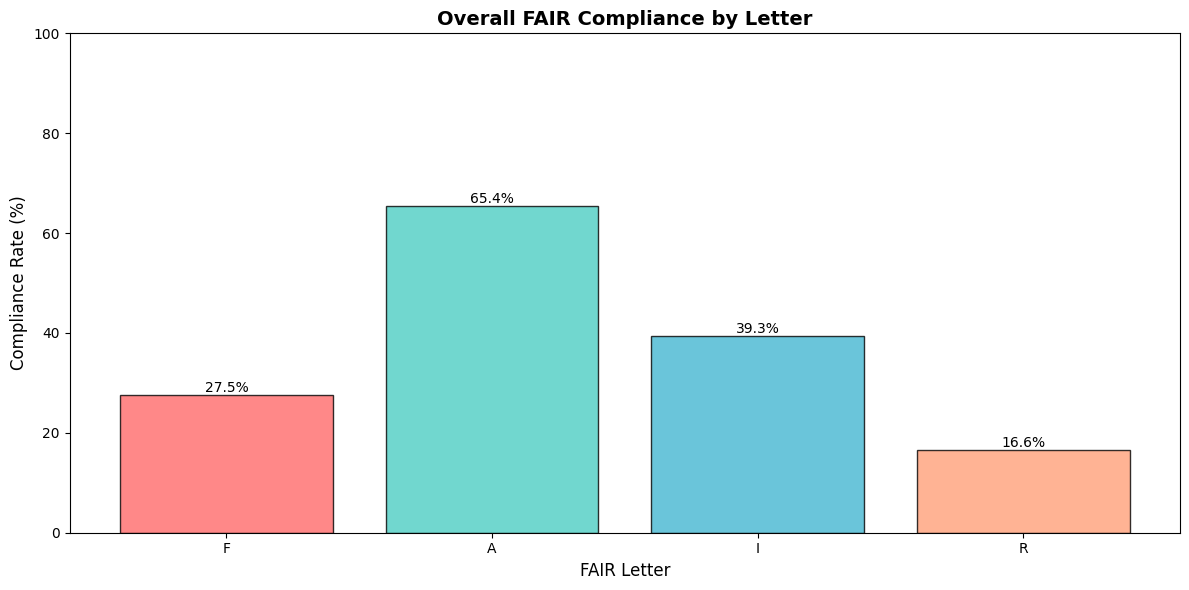

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from plotting.FAIR_compliance import (F, A, I, R, Letter_compliance,
                                      calculate_all_letter_compliance_rates,
                                      calculate_criterion_compliance_rates,
                                      calculate_full_fair_compliance,
                                      print_fair_summary)
from pre_reports.pre_process import scleaned_pandas
from plotting.repository_stats import repo_stats_main

# Load data
sample_file = "results/FAIR Evaluation Results - First Pass Responses_fixed.csv"
drop_cols = ["A1 follow-up: Which of these protocols are available to download the software?","R2 follow-up: Is there a file / project manager tool to help with the installation of other software / libraries?","Is the software itself documented well? Which of the following code readability standards have been implemented?","How long did this form take to complete?","Anything else to note?","Any additional notes for F?","Any additional notes for A?","Any additional notes for I?","Any additional notes for R?" ]
df = scleaned_pandas(sample_file, columns_to_drop=drop_cols, index_col="Paper Name:")
df = df[(df["Are any software artefacts/tools/scripts mentioned in and used in the process of gathering results for the report?"] == "Yes") ]

#Add below to the above line to exclude papers where the artefact is unavailable
#& (df["F1. Software is assigned a globally unique and persistent identifier (DOI)"] != "Artefact Unavailable")

graphs_dir = Path("graphs")
graphs_dir.mkdir(exist_ok=True)


def save_plot(fig, title=None):
    if title is None:
        if fig._suptitle is not None:
            title = fig._suptitle.get_text()
        elif fig.axes:
            title = fig.axes[0].get_title()
        else:
            title = "plot"

    safe_title = re.sub(r"[^A-Za-z0-9]+", "_", title.strip()).strip("_").lower() or "plot"
    output_path = graphs_dir / f"{safe_title}.png"
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to {output_path}")

# Plot full FAIR compliance by letter
compliance_by_letter = calculate_all_letter_compliance_rates(df)

letters = list(compliance_by_letter.keys())
rates = list(compliance_by_letter.values())

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(letters, rates, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'], alpha=0.8, edgecolor='black')
ax.set_ylabel('Compliance Rate (%)', fontsize=12)
ax.set_xlabel('FAIR Letter', fontsize=12)
ax.set_title('Overall FAIR Compliance by Letter', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.style.use('ggplot')
save_plot(fig)
plt.show()


Saved plot to graphs\fair_criterion_compliance_by_letter.png


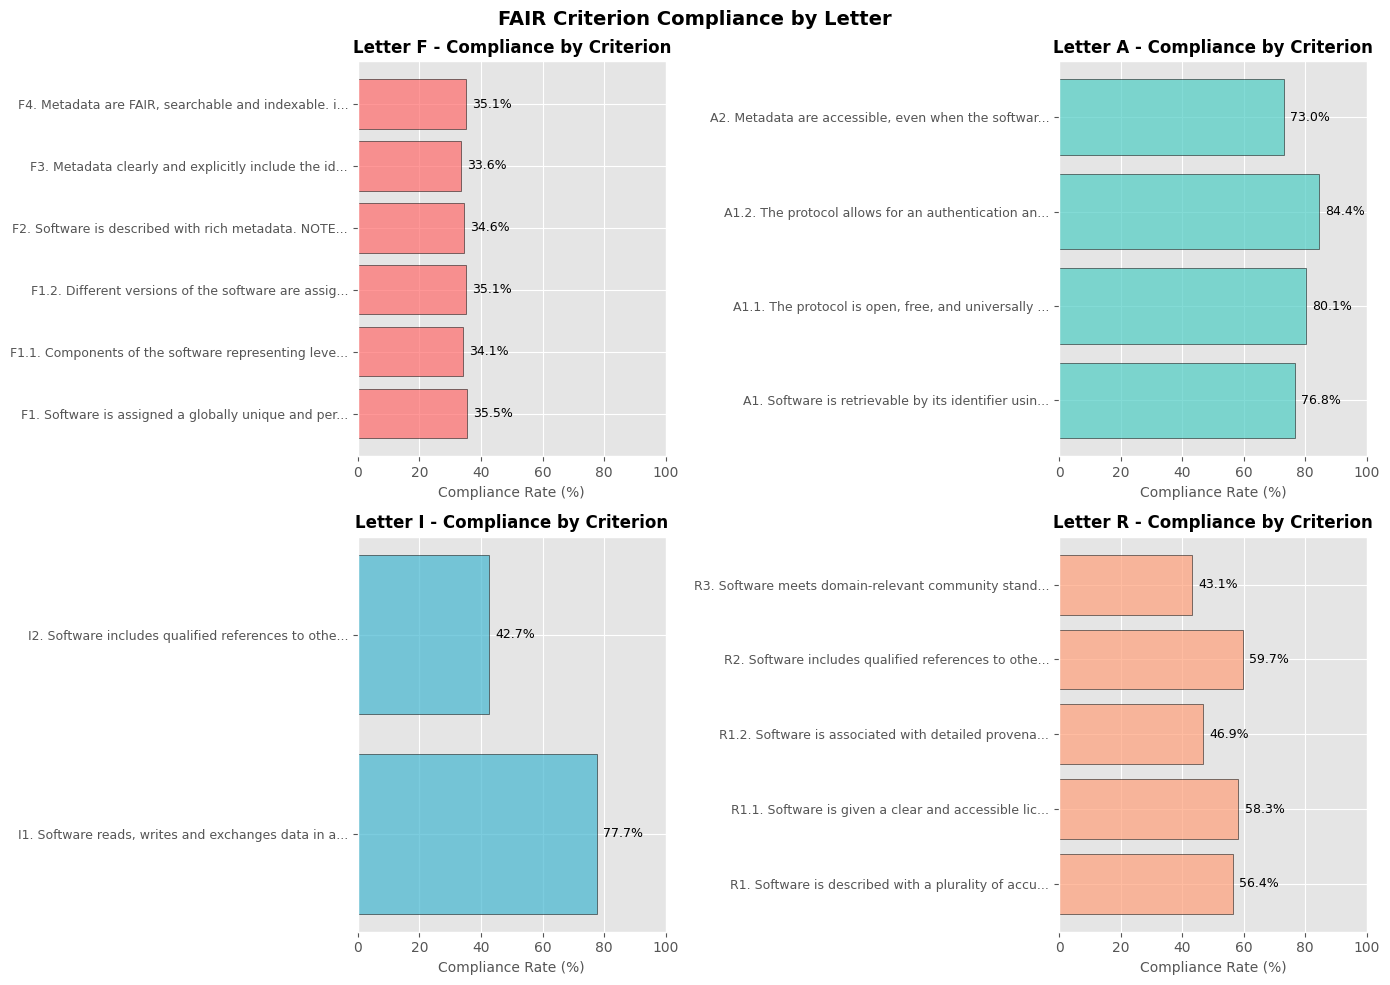

In [2]:
# Individual Letter Compliance Analysis (Using Letter_compliance)

# Create a figure with subplots for each FAIR letter
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

fair_letters = {'F': F, 'A': A, 'I': I, 'R': R}
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx, (letter, criteria) in enumerate(fair_letters.items()):
    # Calculate compliance for each criterion using the new function
    criterion_compliance = calculate_criterion_compliance_rates(df, criteria)
    criterion_labels = []

    for criterion in criteria:
        if criterion in df.columns:
            # Shorten label for readability
            short_label = criterion[:50] + "..." if len(criterion) > 50 else criterion
            criterion_labels.append(short_label)

    # Plot
    ax = axes[idx]
    bars = ax.barh(range(len(criterion_compliance)), criterion_compliance, color=colors[idx], alpha=0.7, edgecolor='black')
    ax.set_yticks(range(len(criterion_labels)))
    ax.set_yticklabels(criterion_labels, fontsize=9)
    ax.set_xlabel('Compliance Rate (%)', fontsize=10)
    ax.set_title(f'Letter {letter} - Compliance by Criterion', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 100)

    # Add value labels
    for i, (bar, value) in enumerate(zip(bars, criterion_compliance)):
        ax.text(value + 2, i, f'{value:.1f}%', va='center', fontsize=9)

fig.suptitle('FAIR Criterion Compliance by Letter', fontsize=14, fontweight='bold')
plt.tight_layout()
save_plot(fig)
plt.show()

Saved plot to graphs\full_fair_compliance_distribution.png


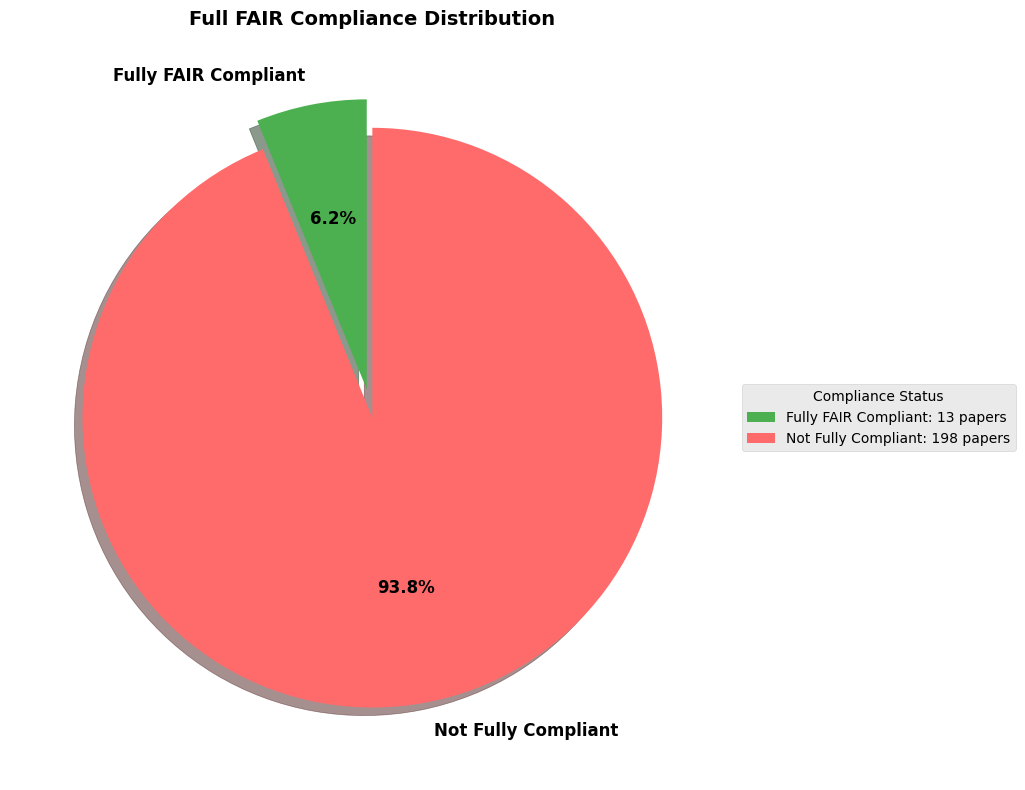

In [17]:
# Full FAIR Compliance Analysis 

compliant_papers, non_compliant_papers = calculate_full_fair_compliance(df)

# Create pie chart showing full FAIR compliance
labels = ['Fully FAIR Compliant', 'Not Fully Compliant']
sizes = [len(compliant_papers), len(non_compliant_papers)]
colors = ['#4CAF50', '#FF6B6B']  # Green for compliant, red for non-compliant
explode = (0.1, 0)  # explode the compliant slice

fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, colors=colors,
                                  autopct='%1.1f%%', startangle=90, shadow=True)

# Style the text
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

ax.set_title('Full FAIR Compliance Distribution\n', fontsize=14, fontweight='bold')

# Add legend with counts
ax.legend(wedges, [f'{label}: {count} papers' for label, count in zip(labels, sizes)],
          title="Compliance Status", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
save_plot(fig)
plt.style.use('ggplot')
plt.show()

# Print summary using the new function

C:\Users\bigey\AppData\Local\Temp\ipykernel_34344\1035302280.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlGn")


Saved plot to graphs\distribution_of_fair_criteria_met_per_paper_bar_color_doi_proportion_in_group.png


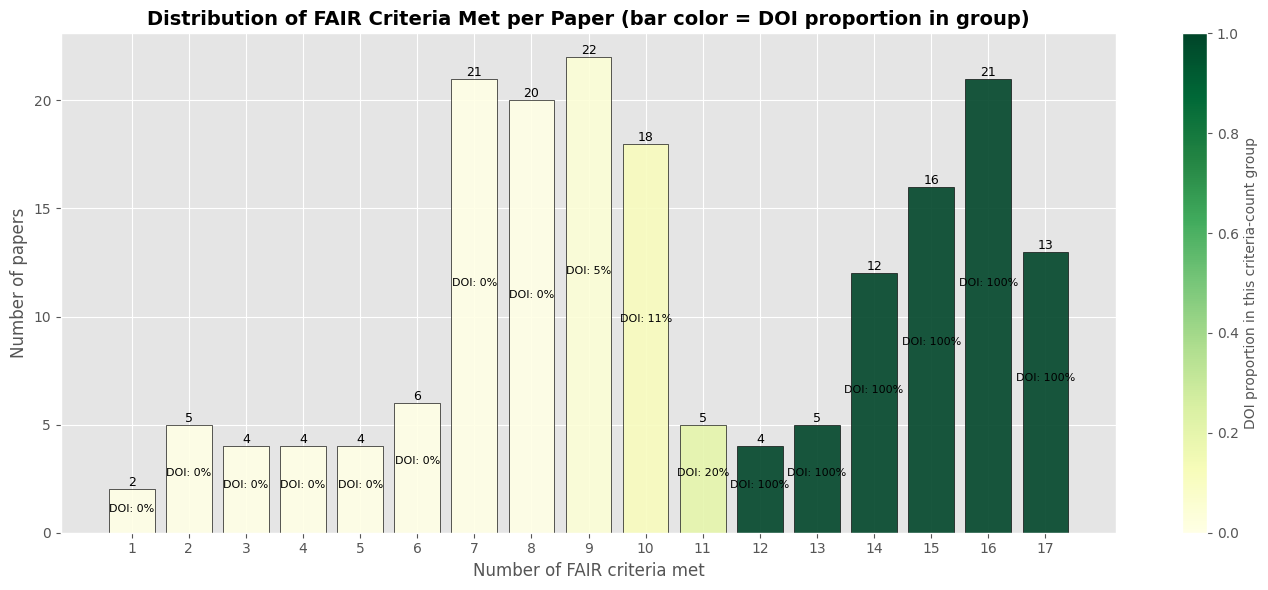

In [4]:
# Distribution of number of FAIR criteria met (1..n)
# Bar colors indicate DOI proportion within each criteria-count group.
from matplotlib import cm
from matplotlib.colors import Normalize
from plotting.FAIR_compliance import is_criterion_compliant, get_value_safely

all_criteria = F + A + I + R
n_criteria = len(all_criteria)
doi_criterion = "F1. Software is assigned a globally unique and persistent identifier (DOI)"

# Compute per-paper counts
criteria_met_per_paper = []
has_doi_per_paper = []

for paper_name in df.index:
    met_count = sum(is_criterion_compliant(df, paper_name, criterion) for criterion in all_criteria)
    criteria_met_per_paper.append(met_count)

    doi_value = get_value_safely(df, paper_name, doi_criterion) if doi_criterion in df.columns else "No"
    has_doi_per_paper.append(str(doi_value).strip().lower() == "yes")

plot_df = pd.DataFrame({
    "criteria_met": criteria_met_per_paper,
    "has_doi": has_doi_per_paper
})

# Build 1..n bins, keeping zero-count bins visible
group_counts = plot_df["criteria_met"].value_counts().reindex(range(1, n_criteria + 1), fill_value=0)
doi_counts = plot_df.groupby("criteria_met")["has_doi"].sum().reindex(range(1, n_criteria + 1), fill_value=0)

# DOI proportion in each group (0 when group is empty)
doi_proportions = (doi_counts / group_counts.replace(0, np.nan)).fillna(0.0)

# Color bars by DOI proportion
norm = Normalize(vmin=0, vmax=1)
cmap = cm.get_cmap("YlGn")
bar_colors = cmap(norm(doi_proportions.values))

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(
    group_counts.index,
    group_counts.values,
    color=bar_colors,
    alpha=0.9,
    edgecolor="black"
)

ax.set_xlabel("Number of FAIR criteria met", fontsize=12)
ax.set_ylabel("Number of papers", fontsize=12)
ax.set_title("Distribution of FAIR Criteria Met per Paper (bar color = DOI proportion in group)", fontsize=14, fontweight="bold")
ax.set_xticks(range(1, n_criteria + 1))

# Add paper-count labels on top of bars
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=9
        )

# Add DOI proportion labels inside bars when possible
for x_val, total, doi_prop in zip(group_counts.index, group_counts.values, doi_proportions.values):
    if total > 0:
        ax.text(
            x_val,
            max(total * 0.55, 0.2),
            f"DOI: {doi_prop:.0%}",
            ha="center",
            va="center",
            fontsize=8,
            color="black"
        )

# Colorbar legend for DOI proportions
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("DOI proportion in this criteria-count group", fontsize=10)

plt.tight_layout()
save_plot(fig)
plt.style.use("ggplot")
plt.show()

Saved plot to graphs\artifact_overlap_between_first_and_second_pass.png


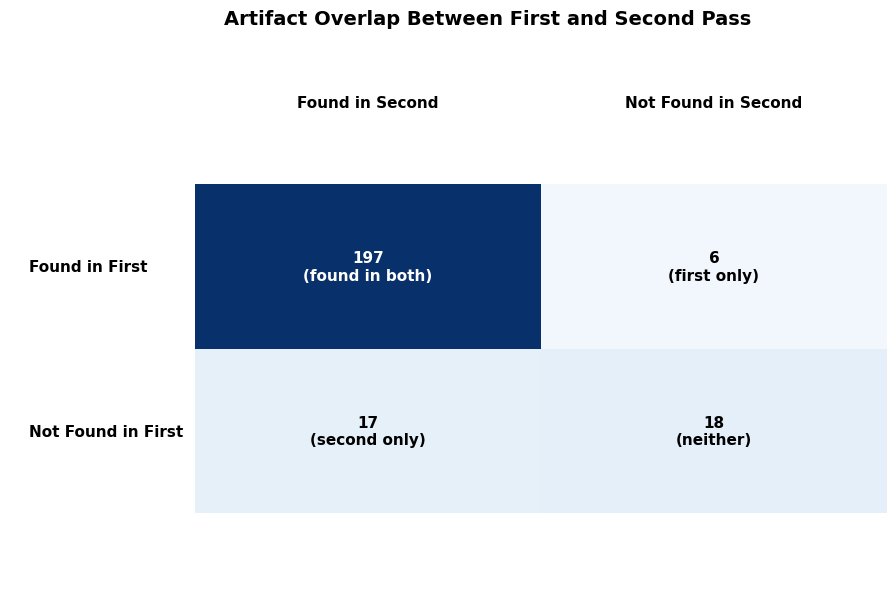

In [16]:
# Artifact overlap between first and second pass
from matplotlib import cm
from matplotlib.colors import Normalize
from pre_reports.pass_comparison_backend import load_pass_pair

artifact_column = "Are any software artefacts/tools/scripts mentioned in and used in the process of gathering results for the report?"
first_pass_df, second_pass_df = load_pass_pair(
    "results/FAIR Evaluation Results - First Pass Responses_fixed.csv",
    "results/FAIR Evaluation Results - Second Pass Responses_fixed.csv",
)

matched_keys = sorted(set(first_pass_df.index) & set(second_pass_df.index))

found_in_both = 0
found_in_first_only = 0
found_in_second_only = 0
found_in_neither = 0

for row_key in matched_keys:
    found_in_first = str(first_pass_df.at[row_key, artifact_column]).strip().lower() == "yes"
    found_in_second = str(second_pass_df.at[row_key, artifact_column]).strip().lower() == "yes"

    if found_in_first and found_in_second:
        found_in_both += 1
    elif found_in_first and not found_in_second:
        found_in_first_only += 1
    elif not found_in_first and found_in_second:
        found_in_second_only += 1
    else:
        found_in_neither += 1

overlap_matrix = np.array([
    [found_in_both, found_in_first_only],
    [found_in_second_only, found_in_neither],
])

fig, ax = plt.subplots(figsize=(9, 6))
ax.axis("off")

norm = Normalize(vmin=0, vmax=max(overlap_matrix.max(), 1))
cmap = plt.get_cmap("Blues")
cell_colours = [[cmap(norm(value)) for value in row] for row in overlap_matrix]
cell_text = [
    [f"{found_in_both}\n(found in both)", f"{found_in_first_only}\n(first only)"],
    [f"{found_in_second_only}\n(second only)", f"{found_in_neither}\n(neither)"]
]

table = ax.table(
    cellText=cell_text,
    cellColours=cell_colours,
    rowLabels=["Found in First", "Not Found in First"],
    colLabels=["Found in Second", "Not Found in Second"],
    cellLoc="center",
    loc="center",
    bbox=[0.12, 0.12, 0.90, 0.90],
)

table.auto_set_font_size(False)
table.set_fontsize(11)

for (row_index, col_index), cell in table.get_celld().items():
    cell.set_linewidth(0)
    if row_index >= 1 and col_index >= 0:
        value = overlap_matrix[row_index - 1, col_index]
        text_color = "white" if value > overlap_matrix.max() * 0.5 else "black"
        cell.get_text().set_color(text_color)
        cell.get_text().set_fontweight("bold")
    else:
        cell.set_facecolor("white")
        cell.get_text().set_fontweight("bold")
        cell.get_text().set_color("black")

ax.set_title("Artifact Overlap Between First and Second Pass", fontsize=14, fontweight="bold", pad=5)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
# cbar = plt.colorbar(sm, ax=ax, fraction=0.05, pad=0.04)
# cbar.set_label("Artifact count", fontsize=10)

plt.tight_layout()
save_plot(fig)
plt.show()

In [ ]:
# ACM badge compliance cascade (wider criteria)
acm_badge_column = "Which (if any) ACM Badges does the report have?"

# Use the wider pass data (no FAIR-essential filtering or dropped columns)
wide_df = scleaned_pandas(sample_file, index_col="Paper Name:")

if acm_badge_column not in wide_df.columns:
    raise ValueError(f"Missing ACM badge column: {acm_badge_column}")

badge_text = wide_df[acm_badge_column].fillna("").astype(str).str.lower()

has_available = badge_text.str.contains("artefact available")
has_functional = badge_text.str.contains("artefact functional")
has_reusable = badge_text.str.contains("artefact reusable")

# Exclusive cascade buckets
no_badge_count = (~has_available & ~has_functional & ~has_reusable).sum()
available_only_count = (has_available & ~has_functional & ~has_reusable).sum()
functional_only_count = (has_available & has_functional & ~has_reusable).sum()
reusable_count = (has_available & has_functional & has_reusable).sum()

cascade_labels = [
    "No badge",
    "Available only",
    "Functional only",
    "Reusable"
]
cascade_counts = [
    int(no_badge_count),
    int(available_only_count),
    int(functional_only_count),
    int(reusable_count)
]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    cascade_labels,
    cascade_counts,
    color=["#B0BEC5", "#90CAF9", "#42A5F5", "#1E88E5"],
    edgecolor="black",
    alpha=0.9
)

ax.set_xlabel("ACM Badge Level", fontsize=12)
ax.set_ylabel("Number of papers", fontsize=12)
ax.set_title("ACM Badge Compliance Cascade", fontsize=14, fontweight="bold")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
save_plot(fig)
plt.show()

First pass: {'Zenodo Only': 29, 'GitHub Only': 103, 'Figshare Only': 8, 'Zenodo and GitHub': 34, 'Figshare and GitHub': 5, 'Anonymous GitHub Only': 9, 'Artefact Unavailable': 25, 'No Artefact': 29, 'Google Sites': 2, 'Other': 2}
Second pass: {'Zenodo Only': 26, 'GitHub Only': 115, 'Figshare Only': 11, 'Zenodo and GitHub': 30, 'Figshare and GitHub': 5, 'Anonymous GitHub Only': 10, 'Artefact Unavailable': 22, 'No Artefact': 16, 'Google Sites': 1, 'Other': 4}


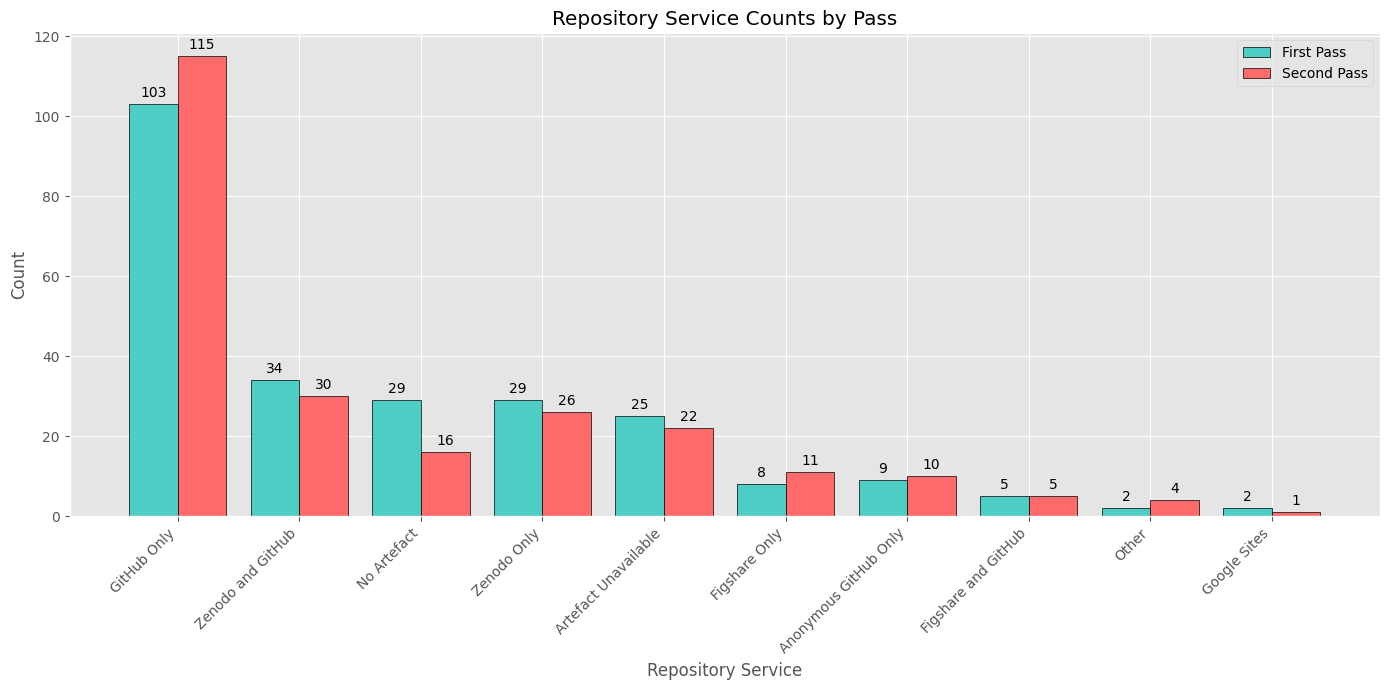

In [7]:
# Repo stats
repo_stats_main()